In [1]:
%config SqlMagic.autopandas = True
%config SqlMagic.feedback = False
%config SqlMagic.displaycon = False

In [2]:
import duckdb
import pandas as pd

%load_ext sql
# %reload_ext sql
conn = duckdb.connect()
%sql conn --alias duckdb

In [3]:
# DAPR - Number of days included in the multiday precipitation total (MDPR)
# SNOW - Snowfall
# WT03 - Thunder
# WT04 - Ice pellets, sleet, snow pellets, or small hail"
# PRCP - Precipitation
# WT05 - Hail (may include small hail)
# TOBS - Temperature at the time of observation
# WT06 - Glaze or rime
# WT07 - Dust, volcanic ash, blowing dust, blowing sand, or blowing obstruction
# WT08 - Smoke or haze
# SNWD - Snow depth
# WT09 - Blowing or drifting snow
# WT01 - Fog, ice fog, or freezing fog (may include heavy fog)
# TMAX - Maximum temperature
# WT02 - Heavy fog or heaving freezing fog (not always distinguished from fog)
# PSUN - Daily percent of possible sunshine for the period
# TAVG - Average Temperature.
# TMIN - Minimum temperature
# MDPR - Multiday precipitation total (use with DAPR and DWPR, if available)
# TSUN - Total sunshine for the period

In [ ]:
# WT01 - Fog, ice fog, or freezing fog (may include heavy fog)
# WT02 - Heavy fog or heaving freezing fog (not always distinguished from fog)
# WT03 - Thunder
# WT04 - Ice pellets, sleet, snow pellets, or small hail"
# WT05 - Hail (may include small hail)
# WT06 - Glaze or rime
# WT07 - Dust, volcanic ash, blowing dust, blowing sand, or blowing obstruction
# WT08 - Smoke or haze
# WT09 - Blowing or drifting snow

In [145]:
%%sql
create or replace table chicago_aqi as
with cte_aqi_raw as (
    select * from 'city_analysis/chicago/aqi_data_*.csv'
)
, cte_aqi_filter as (
    select
          date as date
        , "Site ID" as site_id
        , "Daily AQI Value" as aqi
        , "Local Site Name" as site_name
        , "County" as county
    from cte_aqi_raw
    where 1=1
        and aqi > 100
)
, cte_pre_agg as (
    select
          date
        , max(aqi) as aqi
    from cte_aqi_filter
    group by
        date
)
    select
          year(date) as period
        , count(*) as aqi
    from cte_pre_agg
    group by
        period
    order by period desc

,Count
0,6


In [146]:
%%sql
create or replace table spokane_aqi as
with cte_aqi_raw as (
    select * from 'city_analysis/spokane/aqi_data_*.csv'
)
, cte_aqi_filter as (
    select
          date as date
        , "Site ID" as site_id
        , "Daily AQI Value" as aqi
        , "Local Site Name" as site_name
        , "County" as county
    from cte_aqi_raw
    where 1=1
        and aqi > 100
)
, cte_pre_agg as (
    select
          date
        , max(aqi) as aqi
    from cte_aqi_filter
    group by
        date
)
    select
          year(date) as period
        , count(aqi) as aqi
    from cte_pre_agg
    group by
        period
    order by period desc

,Count
0,4


In [148]:
%%sql
select * from spokane_aqi

,period,aqi
0,2024,1
1,2023,8
2,2022,10
3,2020,9


In [154]:
%%sql
select * from chicago_aqi

,period,aqi
0,2025,1
1,2024,1
2,2023,11
3,2022,3
4,2021,7
5,2020,3


Removing NULLs, if there exists any from period and aqi

<Axes: title={'center': 'spokane_aqi'}, xlabel='period', ylabel='aqi'>

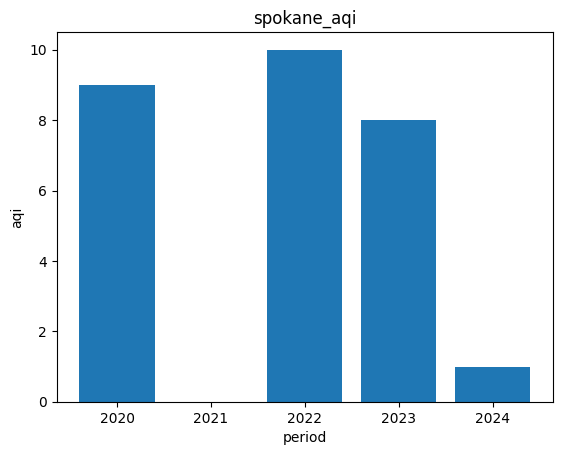

In [152]:
%sqlplot bar --table spokane_aqi --column period aqi

Removing NULLs, if there exists any from period and aqi

<Axes: title={'center': 'chicago_aqi'}, xlabel='period', ylabel='aqi'>

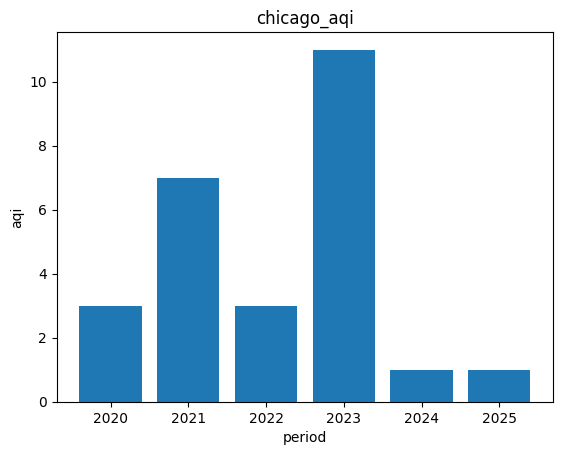

In [153]:
%sqlplot bar --table chicago_aqi --column period aqi

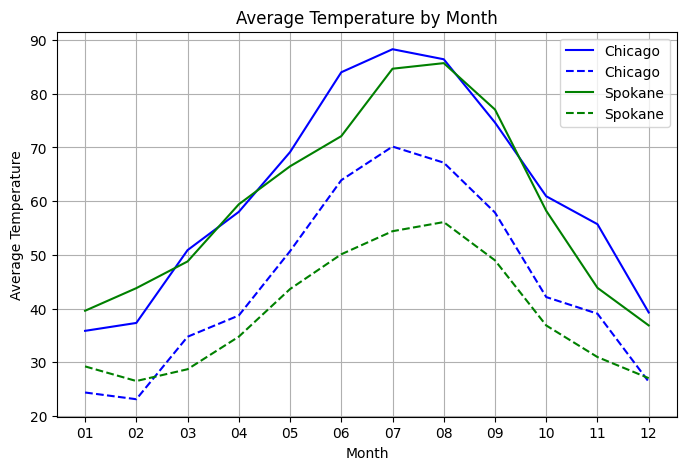

In [138]:
import matplotlib.pyplot as plt

def get_temp(year, city, agg_type):
    return f"""with climate_data as (
        select * from 'city_analysis/{city}/climate_data_10_years.csv'
    )
    , sunshine as (
        select date, cast({agg_type} as double) as temp  from climate_data
        where temp is not null
    )
    select
        avg(temp) as temp
        , strftime('%m', date) as period
    from sunshine
    where 1=1
    and year(date) = {year}
    group by period
    order by period"""

for i in [2020, 2021, 2022, 2023, 2024, 2025][:1]:
    # Query the temperature table into a DataFrame
    chi_max = conn.sql(get_temp(str(i), 'chicago', 'tmax')).df()
    chi_min = conn.sql(get_temp(str(i), 'chicago', 'tmin')).df()

    spok_max = conn.sql(get_temp(str(i), 'spokane', 'tmax')).df()
    spok_min = conn.sql(get_temp(str(i), 'spokane', 'tmin')).df()

    # print(i)

    # Plot
    plt.figure(figsize=(8,5))
    plt.xlabel('Month')
    plt.ylabel('Average Temperature')
    plt.title('Average Temperature by Month')
    plt.grid(True)
    plt.plot(chi_max['period'], chi_max['temp'], linestyle='-', label='Chicago', color='blue')
    plt.plot(chi_min['period'], chi_min['temp'], linestyle='--', label='Chicago', color='blue')

    plt.plot(spok_max['period'], spok_max['temp'], linestyle='-', label='Spokane', color='green')
    plt.plot(spok_min['period'], spok_min['temp'], linestyle='--', label='Spokane', color='green')
    
    plt.legend()
    plt.show()
    